MOHAMED ASLAM-24BAD073

In [ ]:
!pip install -q datasets

In [ ]:
import datasets

print("Datasets installed successfully!")
print("Version:", datasets.__version__)

Datasets installed successfully!
Version: 4.0.0


In [ ]:
!pip install -q "datasets[vision]"

In [ ]:
from datasets import load_dataset

print("Hugging Face Datasets is ready!")

Hugging Face Datasets is ready!


In [ ]:
from transformers import pipeline

PART A — DATASET PREPARATION

In [ ]:
import numpy as np
import tensorflow as tf # Import tensorflow for file downloading
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download the tiny_shakespeare dataset directly
# This URL is commonly used for karpathy's tiny_shakespeare dataset
dataset_path = tf.keras.utils.get_file(
    "tiny_shakespeare.txt",
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
)

# Read the content of the downloaded file
with open(dataset_path, 'r') as f:
    full_text = f.read()

print(f"Successfully loaded text from: {dataset_path}")
print(full_text[:500])

train_text = full_text.lower()

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([train_text])

total_words = min(10000, len(tokenizer.word_index) + 1)

token_list = tokenizer.texts_to_sequences([train_text])[0]

max_sequence_length = 20

sequences = []

for i in range(1, len(token_list)):
    start = max(0, i - max_sequence_length + 1)
    sequences.append(token_list[start:i+1])

sequences = pad_sequences(
    sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

X = sequences[:, :-1]
y = sequences[:, -1]

split = int(0.9 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

print("Vocabulary:", total_words)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

Successfully loaded text from: /root/.keras/datasets/tiny_shakespeare.txt
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
Vocabulary: 10000
X_train: (183679, 19)
y_train: (183679,)
X_val: (20409, 19)
y_val: (20409,)


PART B — RNN MODEL

In [ ]:
# - PART B

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

PART C — TRAINING AND GRAPHS

Epoch 1/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 167s 113ms/step - accuracy: 0.0387 - loss: 6.7224 - val_accuracy: 0.0487 - val_loss: 6.5986
Epoch 2/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 140s 98ms/step - accuracy: 0.0723 - loss: 6.1926 - val_accuracy: 0.0750 - val_loss: 6.3848
Epoch 3/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 132s 92ms/step - accuracy: 0.0911 - loss: 5.8646 - val_accuracy: 0.0851 - val_loss: 6.3203
Epoch 4/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 141s 92ms/step - accuracy: 0.1015 - loss: 5.6020 - val_accuracy: 0.0878 - val_loss: 6.3119
Epoch 5/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 145s 94ms/step - accuracy: 0.1104 - loss: 5.3658 - val_accuracy: 0.0874 - val_loss: 6.3694
Epoch 1: Train Acc=0.0387, Val Acc=0.0487, Train Loss=6.7224, Val Loss=6.5986
Epoch 2: Train Acc=0.0723, Val Acc=0.0750, Train Loss=6.1926, Val Loss=6.3848
Epoch 3: Train Acc=0.0911, Val Acc=0.0851, Train Loss=5.8646, Val Loss=6.3203
Epoch 4: Train Acc=0.1015, Val Acc=0.0878, Train Loss=5.6020, Val Loss=6.3119
Epoch 5: Train Acc=0.1104, 

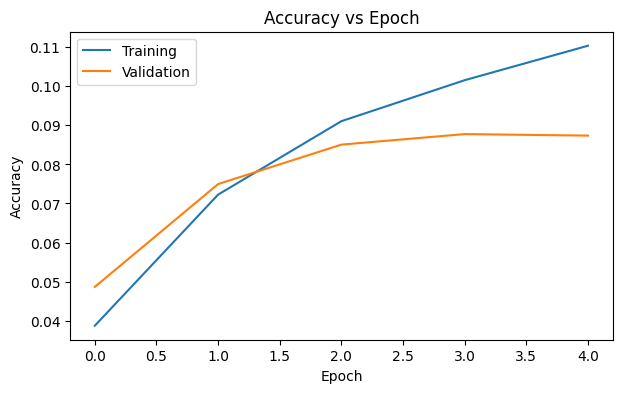

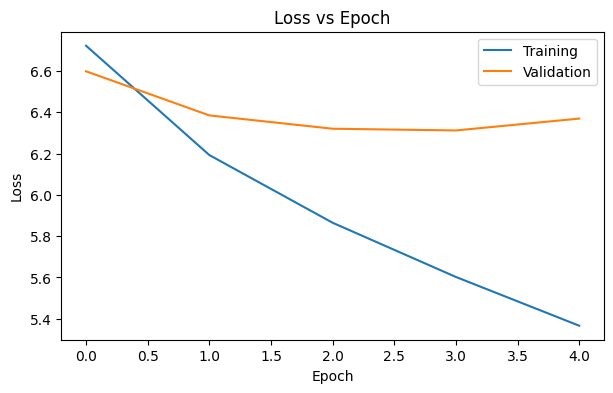

In [ ]:
# - PART C

import matplotlib.pyplot as plt

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128
)

for i in range(5):
    print(
        f"Epoch {i+1}: "
        f"Train Acc={history.history['accuracy'][i]:.4f}, "
        f"Val Acc={history.history['val_accuracy'][i]:.4f}, "
        f"Train Loss={history.history['loss'][i]:.4f}, "
        f"Val Loss={history.history['val_loss'][i]:.4f}"
    )

plt.figure(figsize=(7,4))
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

PART D — TEXT GENERATION

In [ ]:
#- PART D

from tensorflow.keras.preprocessing.sequence import pad_sequences

index_to_word = {
    i: w for w, i in tokenizer.word_index.items()
}

def generate_text(seed, n=20):
    text = seed.lower()

    for _ in range(n):
        seq = tokenizer.texts_to_sequences([text])[0]
        seq = seq[-19:]
        seq = pad_sequences([seq], maxlen=19, padding="pre")

        pred = model.predict(seq, verbose=0)
        word_id = np.argmax(pred[0])

        word = index_to_word.get(word_id)

        if word is None:
            break

        text += " " + word

    return text


seeds = [
    "the king",
    "my lord",
    "thou art",
    "good night",
    "what is"
]

for seed in seeds:
    print("\nSeed:", seed)
    print(generate_text(seed, 20))

model.save("24BAD073_tiny_shakespeare_rnn.keras")


Seed: the king
the king henry vi aumerle fie fie fie i am a cause to the king edward iv i am a king and

Seed: my lord
my lord mayor fie fie fie fie fie fie fie fie fie fie fie fie fie i am a thing to be

Seed: thou art
thou art deceived pompey fie fie fie fie fie fie fie fie fie i am a thing to be a <OOV> of

Seed: good night
good night pompey pompey sir pompey pompey sir sir sir sir sir sir sir sir sir sir sir sir sir sir sir

Seed: what is
what is done matter pompey pompey sir sir sir you are you to your voices if you have you have been a
